In [1]:
import os
import math
import cartopy.crs as ccrs
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import colormaps as cm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mpl_cm

from graphcast.losses import normalized_latitude_weights
from omegaconf import OmegaConf

import graphufs
from graphufs.datasets import Dataset
from graphufs.lineplot import LinePlotter
from graphcast.model_utils import stacked_to_dataset
from graphufs.stacked_utils import get_channel_index

# this may need to be changed later
from prototypes.ocn_only.emulator import OcnEvaluator, OcnTrainer

In [2]:
plt.style.use("graphufs.plotstyle")

In [5]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        print("num of missing samples:", num_missing_samples )
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [6]:
def calculate_sq_error_for_model(model_pred, ref_truth):
    """
    Calculates sq_error for a given model against a truth reference.
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    sq_error_vars = {}

    for var in model_pred.data_vars:
        # Determine the correct mask to use for this variable (with or without depth)
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
        # Compute error and apply mask
        error = (model_pred[var] - ref_truth[var]) * current_mask
        
        sq_error_vars[var] = error.compute()**2
        
    return sq_error_vars

In [7]:
def calculate_rmse(sqerr_da, apply_weighting=False, depth_level=0, 
                   depth_unit="dimensionless"):
    """
    Calculates the Root Mean Squared Error from a squared error DataArray.
    
    This function correctly preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in sqerr_da.dims:
        if depth_unit.lower() == "dimensionless": 
            sqerr_da = sqerr_da.isel(z_l=depth_level)
        else:
            sqerr_da = sqerr_da.sel(z_l=depth_level, method="nearest")
            
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(sqerr_da)
        sqerr_da = sqerr_da * weights.astype(sqerr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    # The 'time' dimension (or 'init_time') holds the samples for the CI.
    dims_to_avg = [dim for dim in sqerr_da.dims if dim not in ["lead_time", "time"]]
    
    # Calculate the mean over spatial dimensions and take the square root
    rmse_da = np.sqrt(sqerr_da.mean(dim=dims_to_avg))
    
    return rmse_da

## Setup the meta and compute RMSE

In [9]:
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
SAMPLE_STRIDE = 5

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-Maha",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]

In [10]:
# ---- Main computation block ----
# Initialize dictionaries to store all results
all_sq_error = {}
    
# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")
        
    all_sq_error[model_name] = {}
        
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            run = "R5" if model_config['timestep'] == "24h" else "R4"
            expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            duration = "240h"
            location = os.path.join(SCRATCH_DIR, model_config["model_type"], run, f"inference_{expt}/validation/")
            fname = f"{location}/replay.{duration}.zarr"
        else:
            infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
            location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
            fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname)
            
        # Calculate all metrics for this model against this truth
        sq_err = calculate_sq_error_for_model(model_pred, ref_truth)
            
        # Store results
        all_sq_error[model_name][truth_name] = sq_err

print("\n --- Metric calculation complete!! ---")


Processing Model: Emulator-24h-MSE
Comparing against truth: Replay ...

Processing Model: Emulator-24h-Maha
Comparing against truth: Replay ...

 --- Metric calculation complete!! ---


In [1]:
# units
units = {}
units["SSH"] = "m"
units["so"] = "psu"
units["temp"] = "degC"
units["uo"] = "m/s"
units["vo"] = "m/s"

# error bounds
error_bounds = {}
error_bounds["SSH"] = {"vmin":0, "vmax":0.1}  # 0-15 cm
error_bounds["so"] = {"vmin":0, "vmax":0.2}   # 0-0.4 psu
error_bounds["temp"] = {"vmin":0, "vmax":0.6} # 0-0.5 degC
error_bounds["uo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
error_bounds["vo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s

In [2]:
vars_2d = ["SSH"]
vars_3d = list(set(model_pred.data_vars) - set(vars_2d))

NameError: name 'model_pred' is not defined

In [12]:
def plot_rmse_vs_leadtime_2d(ax, 
                             da: xr.DataArray, 
                             var_name: str = None, 
                             unit: str = None, 
                             timestep: str = "6h", 
                             forecast_days: int = 10, 
                             label: str = "",
                             vmin: float = None,
                             vmax: float = None,
                             show_title: bool = True,
                             apply_latitude_weighting: bool = True):
    """
    Plot RMSE vs lead_time for a 2D variable.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - forecast_days: number of days of forecasts
    - label: label to use in legend
    - vmin, vmax: RMSE bounds
    """
    # convert lead time to hours/days
    lead_time_hours = da["lead_time"].values / np.timedelta64(1, "h")
    lead_time_days = lead_time_hours / 24

    # subsample to the end of every day
    steps_per_day = int(24 / int(timestep[:-1])) 
    ts_to_plot = np.arange(steps_per_day-1, forecast_days*steps_per_day, steps_per_day)

    # get values to plot
    values = da.values[ts_to_plot]
    days = lead_time_days[ts_to_plot]

    # vmin/vmax
    vmin = vmin if vmin is not None else error_bounds[var_name]["vmin"]
    vmax = vmax if vmax is not None else error_bounds[var_name]["vmax"]

    # plot
    ax.plot(days, values, linewidth=2, label=label,)
    ax.set_ylim(vmin, vmax)

    # axis labels
    xlabel = f"Forecast Lead Time [days]"
    ylabel = f"RMSE [{unit}]" if unit is not None else f"RMSE [{units[var_name]}]"
    if apply_latitude_weighting:
        ylabel = f"LW-{ylabel}"
    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)

    # axis ticks
    ax.tick_params(axis="x", labelsize=14,)
    ax.tick_params(axis="y", labelsize=14,)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}", fontsize=16,)
    
    return ax

In [13]:
def plot_spatial_rmse(ax, 
                      da: xr.DataArray, 
                      var_name: str = None, 
                      unit: str = None, 
                      label: str = "",
                      show_title: bool = True,
                      apply_latitude_weighting: bool = True,
                      **kwargs):
    """
    Plot spatial map of RMSE for a given variable and lead time.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - label: label to use in legend
    - vmin, vmax: RMSE bounds
    """

    da.plot(ax=ax, transform=ccrs.PlateCarree(), **kwargs)
    ax.coastlines(alpha=0.5)
    if show_title:
        ax.set_title(label)

    leadtime = pd.to_timedelta(da.lead_time.values, unit="D")
    title = f"RMSE [in {unit}], {var_name}, lead_time={leadtime}"
    if apply_latitude_weighting:
        title = f"LW-{title}"
    plt.suptitle(title)
    
    return ax

In [20]:
def plot_depth_vs_leadtime(ax, 
                           da: xr.DataArray, 
                           var_name: str = "Variable", 
                           unit: str = "units", 
                           timestep: str = "6h", 
                           label: str = "",
                           vmin: float = None,
                           vmax: float = None,
                           cmap=mpl_cm.plasma,
                           show_title: bool = True,
                           show_cbar: bool = True,
                           clabel: str = "",):
    """
    Plot Depth vs Lead Time as a heatmap (image plot) with error intensity.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time", "z_l")
    - var_name: Name of the variable
    - unit: Unit of the variable
    - timestep: time step of the forecast (must be in hours, e.g., "6h")
    - label: label to use in title
    - vmin, vmax: Colorbar bounds for the error/variable
    - cmap: colormap
    - show_title: boolean to toggle title
    - show_cbar: boolean to toggle colorbar
    - clabel: colorbar label
    """

    # 1. Check relevant axes
    if not {"lead_time", "z_l"}.issubset(set(da.dims)):
        raise ValueError(f"Expected 'lead_time' and 'z_l' dimensions, found {da.dims}")
    
    # 2. Prepare Coordinate for X-Axis (Lead Time in Days)
    # We convert the raw lead_time index into 'Days' for a readable X-axis.
    timestep_int = int(timestep[:-1]) # e.g., extracts 6 from "6h"
    
    # Formula: Time (days) = (Index + 1) * (Hours per step) / 24
    # We create a new DataArray for plotting to avoid modifying the original 'da' in place
    da_plot = da.copy()
    
    # If lead_time is just indices (0, 1, 2...), generate physical time array
    if np.issubdtype(da.lead_time.dtype, np.integer) or np.issubdtype(da.lead_time.dtype, np.floating):
        days_coord = (np.arange(len(da.lead_time)) + 1) * timestep_int / 24.0
        da_plot = da_plot.assign_coords(lead_time=days_coord)
        xlabel = "Forecast Lead Time [days]"
    else:
        # If lead_time is already a datetime object or similar, use it as is
        xlabel = "Forecast Lead Time"

    # 3. Setup Colorbar Bounds
    # You might want to define default error_bounds dictionary externally or handle here
    # For now, we use the provided vmin/vmax or let matplotlib decide defaults
    if vmin is None: vmin = da_plot.min().item()
    if vmax is None: vmax = da_plot.max().item()

    # 4. Plotting (pcolormesh)
    # x='lead_time' ensures time is on X-axis, y='z_l' ensures depth is on Y-axis
    cbar_kwargs = {"label": clabel} if show_cbar else None
    
    mesh = da_plot.plot.pcolormesh(
        ax=ax,
        x="lead_time",
        y="z_l",
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        add_colorbar=show_cbar,
        cbar_kwargs=cbar_kwargs
    )

    # 5. Axis Formatting
    ax.set_ylabel("Depth [m]", fontsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
    
    # Invert Y-axis so the ocean surface (0m) is at the top
    ax.invert_yaxis()

    # 6. Title
    if show_title:
        title_text = f"{var_name}"
        if label:
            title_text += f" ({label})"
        ax.set_title(title_text, fontsize=16)

    return ax

## Plot depth vs lead time pcolormesh plot (with relative difference)

var_name: so


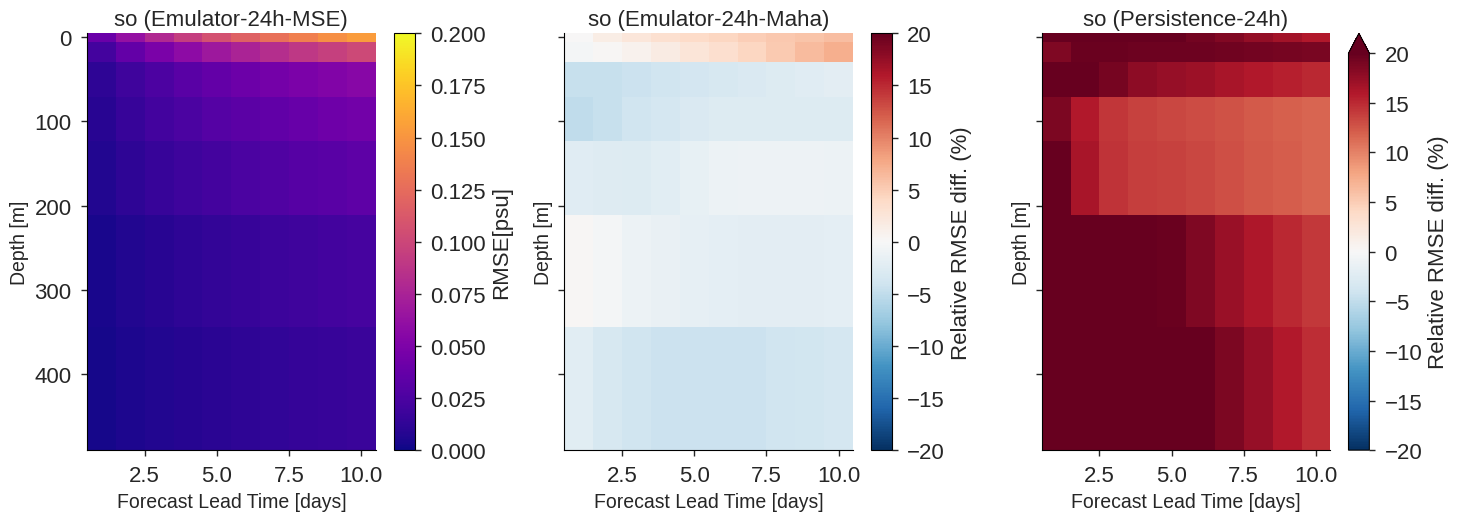

var_name: temp


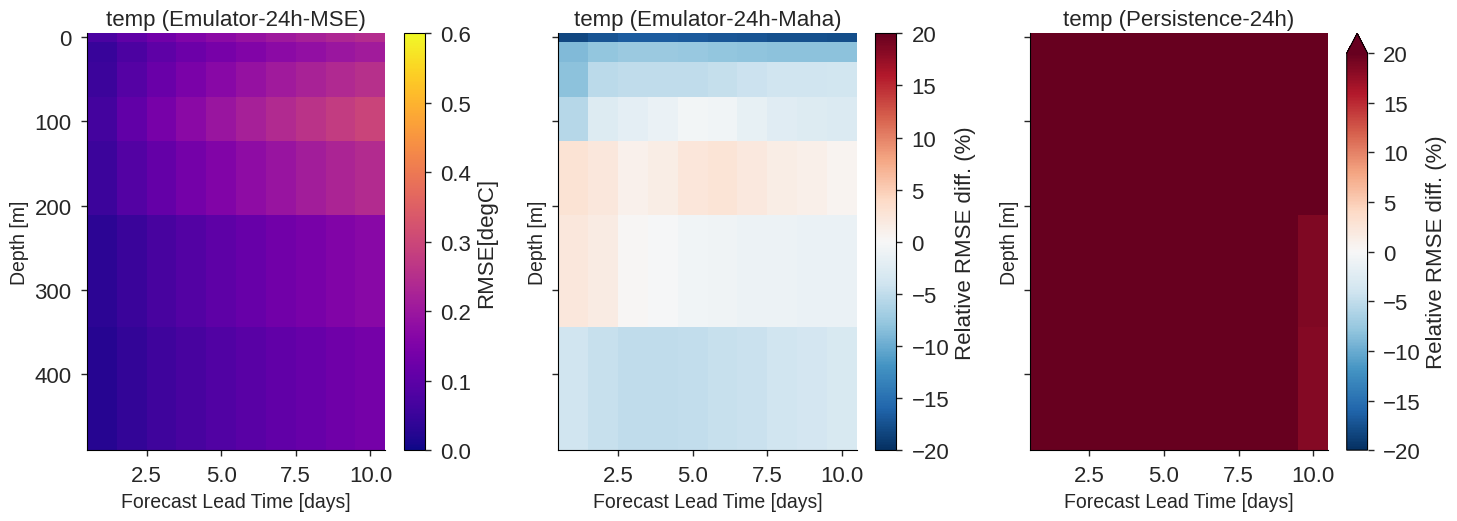

var_name: uo


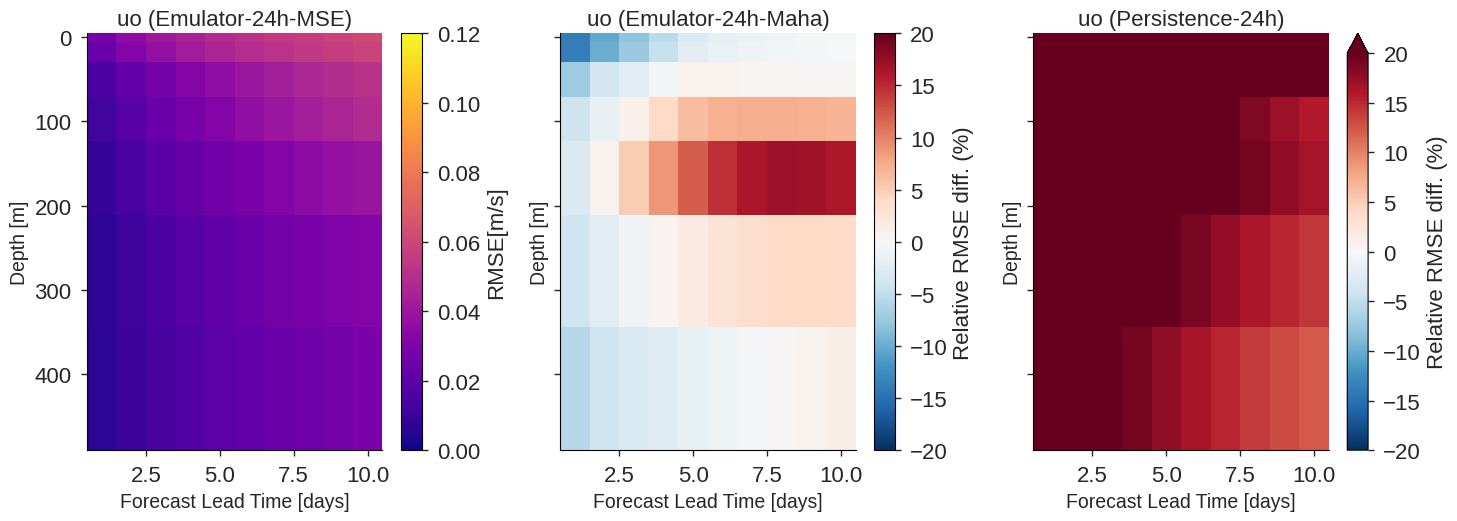

var_name: vo


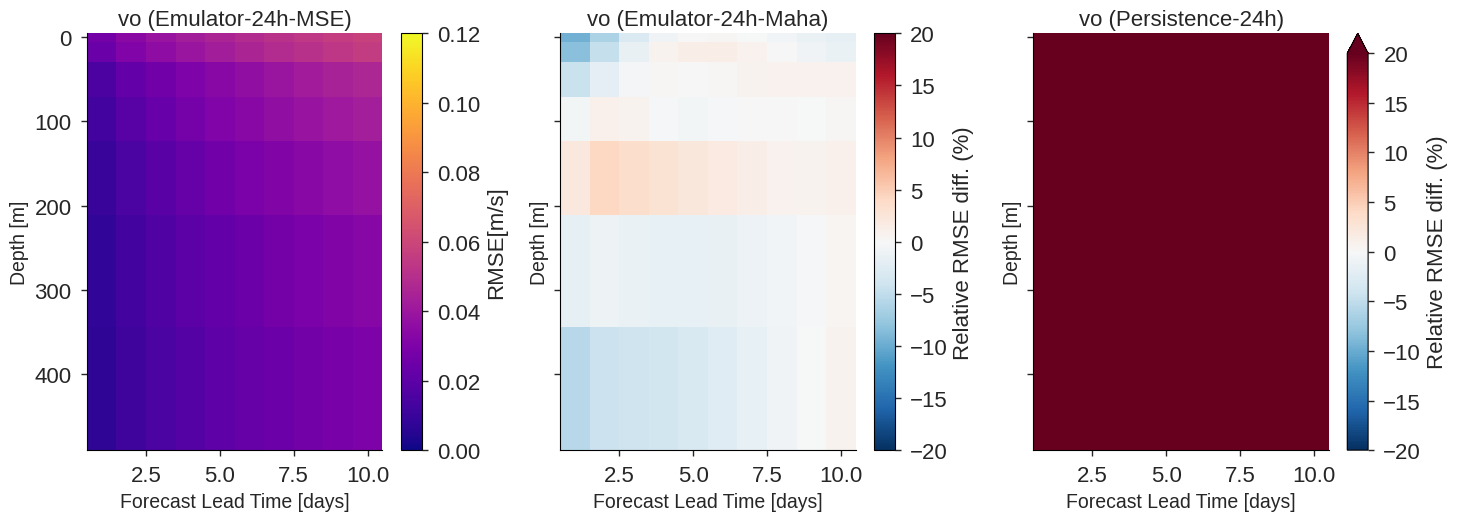

In [23]:
vars_3d.sort()
n_vars = len(vars_3d)
save_plot = True
apply_latitude_weighting = False

reference_model = MODELS_CONFIG[0]['name']

for truth in TRUTHS:

    for var_name in vars_3d:
        
        ncols = len(MODELS_CONFIG)
        nrows = 1

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                                 figsize=(5.5 * ncols, 5.5 * nrows), sharey = "all",)
    
        print("var_name:", var_name)
            
        for j, model in enumerate(MODELS_CONFIG):
            
            ax = axes[j]
            model_name = model['name']

            # Compute RMSE, averaged over all non-lead_time/lat dims
            sqerr = all_sq_error[model_name][truth][var_name]
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))
            if model_name == reference_model:
                vmin=0; vmax=error_bounds[var_name]["vmax"]
                da_reference = da
                clabel = "RMSE" + f"[{units.get(var_name)}]" 
                if apply_latitude_weighting:
                    clabel = "LW-" + xlabel
                cmap = mpl_cm.plasma
            else:
                vmin=-20; vmax=20
                try:
                    da = (da - da_reference)*100/da_reference
                except AttributeError as e:
                    print(f"Make sure that the reference model is the first in the models list: {e}")                    
                clabel = "Relative RMSE diff. (%)"
                cmap=mpl_cm.RdBu_r
                
            ax = plot_depth_vs_leadtime(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=model['timestep'],
                    label=f"{model['name']}",
                    vmin=vmin, vmax=vmax,
                    cmap=cmap,
                    show_title=True,
                    show_cbar=True,
                    clabel=clabel,
            )
        
        # Remove any unused axes
        for idx in range(len(vars_3d), nrows * ncols):
            fig.delaxes(axes[idx // ncols][idx % ncols])

        # improve the layout
        plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right (90% width)
        
        # Add shared colorbar
        #cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        #sm = mpl_cm.ScalarMappable(cmap=cmap, norm=norm)
        #sm.set_array([])
        #cbar = fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time (days)",
        #                    orientation="vertical", fraction=0.05, pad=0.02)
        #cbar.ax.tick_params(labelsize=14)
        #cbar.set_label(label="Forecast Lead Time [days]", size=14)

        #fig.suptitle(f"Intermodel comparison of RMSE vs depth for {var_name}", fontsize=14)

        # Save plot
        if save_plot:
            figname = f"RMSE_and_Normalized_RMSE_diff_vs_depth_{var_name}_MSE-vs-maha_against_{truth}_ocn-only_24h_1IC_coarseTop.png"
            if apply_latitude_weighting:
                figname = f"LW-{figname}"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()